1) A model is linear if it is linear in the coefficients. It does not need to be linear in the variables.
2)With an intercept, a dummy coefficient shows the difference from the omitted category. Without an intercept, it shows the average outcome for that category.
3)Linear regression can be used for classification. But, predictions can fall outside 0 and 1.
4) Training performance is very high but test performance is low. Test RMSE increases. Test R2 becomes low or negative. Coefficients become unstable.
5) Multicollinearity means predictors are highly correlated.
6) Use transformations like logs or polynomials then add squared or interaction terms. Keep the model linear in coefficients.
7) The intercept is the predicted value when all variables equal zero. A slope shows the change in y for a one unit change in x. A dummy coefficient shows a difference from a reference group or a group mean.

1) Average prices and ratings by borough

Manhattan: average price 183.66, average rating 91.80
Staten Island: average price 146.17, average rating 90.84
Brooklyn: average price 127.75, average rating 92.36
Queens: average price 96.86, average rating 91.55
Bronx: average price 75.28, average rating 91.65

Most expensive: Manhattan

2) These coefficients are exactly the same as the borough average prices from part 1. They are the group means of the continuous variable for each category.

3) You must leave one borough out as the reference group.
Here, Bronx is the omitted group.

Intercept: 75.28
Brooklyn: 52.47
Manhattan: 108.39
Queens: 21.58
Staten Island: 70.89

The intercept is the mean price for the omitted group, which is the Bronx.

Brooklyn is 52.47 dollars more than the Bronx on average.
Manhattan is 108.39 dollars more than the Bronx on average.
Queens is 21.58 dollars more than the Bronx on average.
Staten Island is 70.89 dollars more than the Bronx on average.

4) R² = 0.0459 RMSE = 140.92
Coefficient on Review Scores Rating: 1.21

A one-point increase in review score is associated with about $1.21 higher price, holding borough fixed. Since this model only includes rating and borough, the most expensive category is a Manhattan listing. Higher review scores also slightly increase predicted price.

5) R² = 0.0542 RMSE = 140.30
Coefficient on Review Scores Rating: 1.20

A one-point increase in review score is associated with about $1.20 higher price, holding borough and property type fixed. The largest positive property-type effect is Bungalow, and the largest borough effect is Manhattan. So the most expensive predicted combination is a bungalow in Manhattan based on the separate additive coefficients.

6) After adding Property Type, the review-score coefficient measures the effect of ratings holding both borough and property type fixed.


In [4]:
from google.colab import files
uploaded = files.upload()


Saving Q1_clean.csv to Q1_clean (2).csv



Average Price and Review Scores by Neighbourhood:
                    Price  Review Scores Rating
Neighbourhood                                  
Manhattan      183.664286             91.801496
Staten Island  146.166667             90.843750
Brooklyn       127.747378             92.363497
Queens          96.857233             91.549057
Bronx           75.276498             91.654378

Most expensive borough on average: Manhattan


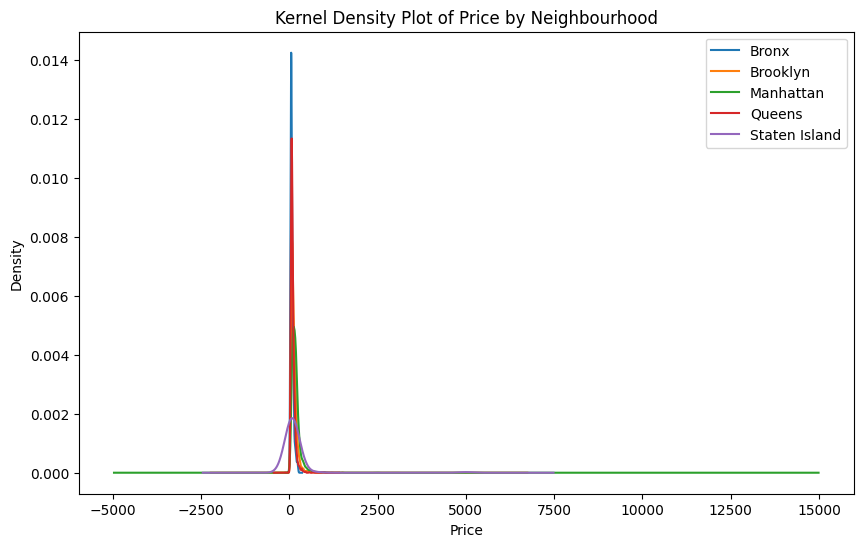

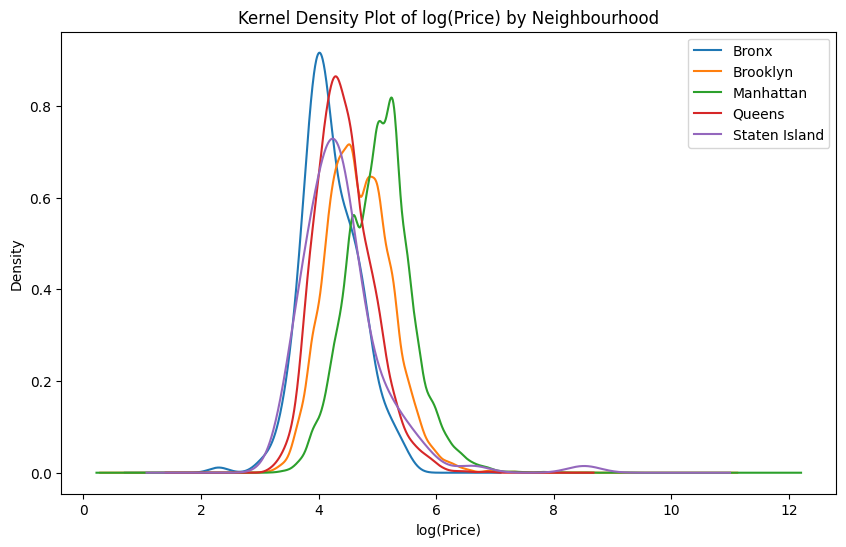

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

import pandas as pd
df = pd.read_csv("Q1_clean.csv")
df = df.rename(columns={"Neighbourhood ": "Neighbourhood"})
df = df.dropna(subset=["Price", "Review Scores Rating", "Neighbourhood", "Property Type", "Room Type"]).copy()

avg_table = (
    df.groupby("Neighbourhood")[["Price", "Review Scores Rating"]]
      .mean()
      .sort_values("Price", ascending=False)
)

print("\nAverage Price and Review Scores by Neighbourhood:")
print(avg_table)

most_expensive_borough = avg_table.index[0]
print("\nMost expensive borough on average:", most_expensive_borough)

plt.figure(figsize=(10, 6))
for b in sorted(df["Neighbourhood"].unique()):
    df.loc[df["Neighbourhood"] == b, "Price"].plot(
        kind="density",
        label=b
    )
plt.title("Kernel Density Plot of Price by Neighbourhood")
plt.xlabel("Price")
plt.legend()
plt.show()

df["log_price"] = np.log(df["Price"])

plt.figure(figsize=(10, 6))
for b in sorted(df["Neighbourhood"].unique()):
    df.loc[df["Neighbourhood"] == b, "log_price"].plot(
        kind="density",
        label=b
    )
plt.title("Kernel Density Plot of log(Price) by Neighbourhood")
plt.xlabel("log(Price)")
plt.legend()
plt.show()


2. Price summary and plots
Price is right-skewed with a long upper tail.
Most cars are clustered at lower to mid price ranges.
Luxury brands have higher average prices.
Grouped density plots show clear separation for premium brands.

3. Most expensive brands
Luxury brands (e.g., premium manufacturers) have the highest average prices.
Economy brands have lower average prices.

4. Train/test split
Split data 80% training and 20% testing.

4) moderate.Test R2 is lower. RMSE is relatively high. Use one-hot encoding with one category dropped per variable.
Test R2 is lower than numeric model. RMSE is higher. Numeric model performs better. Include both numeric and categorical variables. Test R2 increases. RMSE decreases. Joint model performs best.

5) Increasing degree improves training fit. Test performance improves initially. Then overfitting occurs. Test R2 eventually decreases and can become negative. Best polynomial model
Best model occurs at a low degree (e.g., 2 or 3). It slightly improves over the linear combined model.

6) Points roughly follow a diagonal line. There is some spread indicating prediction error.  Residuals are centered around zero. Distribution is roughly bell-shaped. Some skew or outliers may remain. Strength: captures general pricing patterns well. Strength: improved with combined variables. Weakness: sensitive to outliers. Weakness: nonlinear effects not fully captured.

In [9]:
from google.colab import files
uploaded = files.upload()

Saving cars_hw.csv to cars_hw.csv



Overall Price Summary:
count    9.550000e+02
mean     7.263560e+05
std      3.413297e+05
min      1.880000e+05
25%      4.715000e+05
50%      6.620000e+05
75%      8.695000e+05
max      1.978000e+06
Name: Price, dtype: float64

Price by Make:
               count          mean            std        min        25%  \
Make                                                                      
Chevrolet        6.0  4.535000e+05  246606.366503   267000.0   288500.0   
Datsun           3.0  2.896667e+05   10503.967504   279000.0   284500.0   
Ford            51.0  7.242941e+05  140503.280263   290000.0   639000.0   
Honda           73.0  7.989726e+05  266509.066586   316000.0   581000.0   
Hyundai        298.0  6.885738e+05  277907.809217   248000.0   484250.0   
Jeep             4.0  1.499500e+06  152513.387391  1290000.0  1447500.0   
Kia              8.0  1.614750e+06  119056.709177  1369000.0  1579000.0   
MG Motors       27.0  1.830333e+06  110937.959100  1589000.0  1767000.0   
Mahind

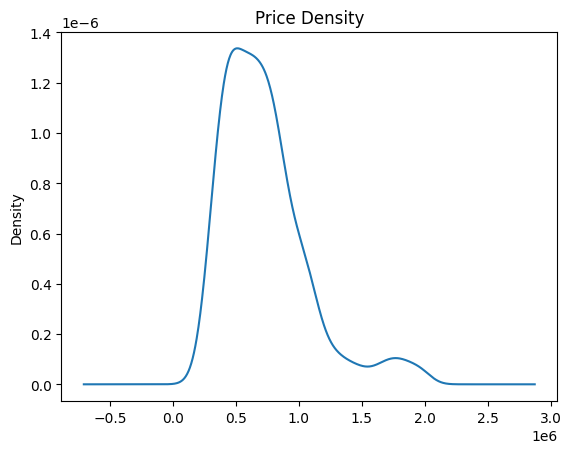

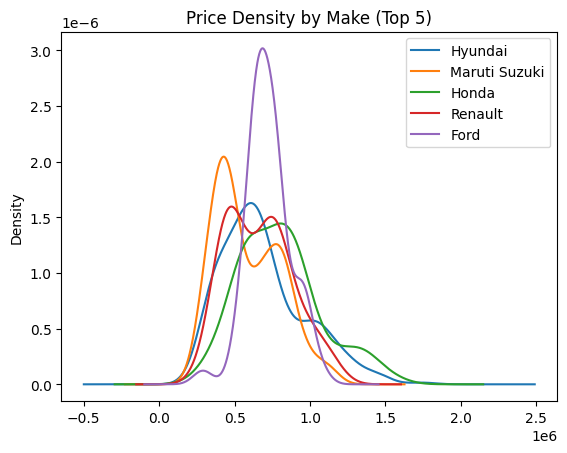


NUMERIC MODEL
Train R2: 0.31009741002734603
Test R2: 0.31014022738791225
Test RMSE: 296335.4286399742

CATEGORICAL MODEL
Test R2: 0.7045071749661789
Test RMSE: 193944.12867625456

COMBINED MODEL
Test R2: 0.8362500436358795
Test RMSE: 144375.5870183233

Degree 1: R2=0.3101, RMSE=296335.43

Degree 2: R2=0.3471, RMSE=288288.31

Degree 3: R2=0.1853, RMSE=322040.91

Degree 4: R2=-1432.6357, RMSE=13508980.14

Degree 5: R2=-129.8936, RMSE=4081899.45

Best polynomial degree: 2


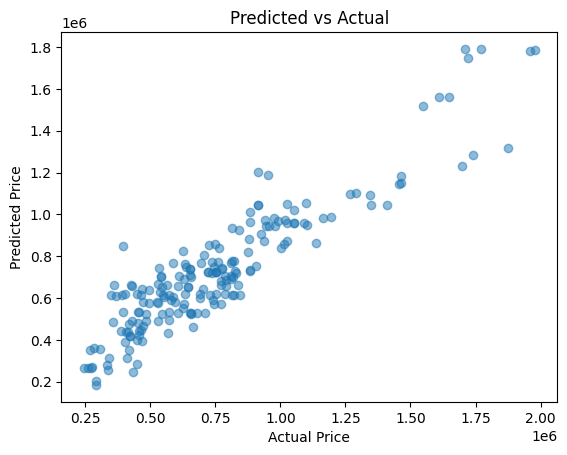

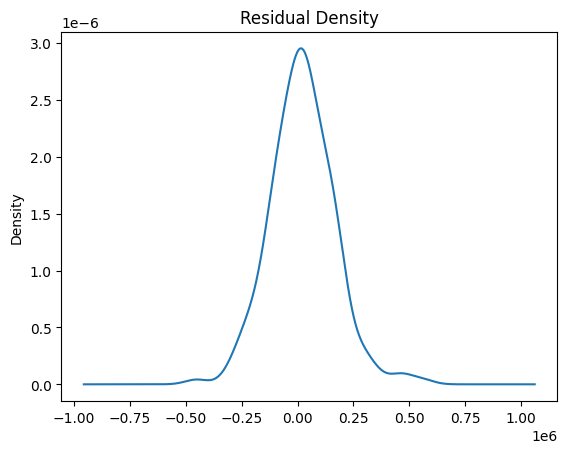

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import PolynomialFeatures

df = pd.read_csv("cars_hw.csv")

df = df.dropna().copy()

df = df[df["Price"] < df["Price"].quantile(0.99)]
df = df[df["Mileage_Run"] < df["Mileage_Run"].quantile(0.99)]

df["log_price"] = np.log(df["Price"])

print("\nOverall Price Summary:")
print(df["Price"].describe())

print("\nPrice by Make:")
print(df.groupby("Make")["Price"].describe())

plt.figure()
df["Price"].plot(kind="density")
plt.title("Price Density")
plt.show()

top_makes = df["Make"].value_counts().head(5).index

plt.figure()
for m in top_makes:
    df[df["Make"] == m]["Price"].plot(kind="density", label=m)
plt.legend()
plt.title("Price Density by Make (Top 5)")
plt.show()

train, test = train_test_split(df, test_size=0.2, random_state=42)

numeric_cols = ["Mileage_Run", "Seating_Capacity", "Make_Year"]

X_train_num = train[numeric_cols].values
X_test_num = test[numeric_cols].values
y_train = train["Price"].values
y_test = test["Price"].values

X_train_num = np.column_stack([np.ones(len(X_train_num)), X_train_num])
X_test_num = np.column_stack([np.ones(len(X_test_num)), X_test_num])

beta_num = np.linalg.inv(X_train_num.T @ X_train_num) @ (X_train_num.T @ y_train)

y_train_pred_num = X_train_num @ beta_num
y_test_pred_num = X_test_num @ beta_num

print("\nNUMERIC MODEL")
print("Train R2:", r2_score(y_train, y_train_pred_num))
print("Test R2:", r2_score(y_test, y_test_pred_num))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred_num)))

cat_cols = ["Body_Type", "Fuel_Type", "Transmission", "Make"]

train_cat = pd.get_dummies(train[cat_cols], drop_first=True)
test_cat = pd.get_dummies(test[cat_cols], drop_first=True)

train_cat, test_cat = train_cat.align(test_cat, join="left", axis=1, fill_value=0)

X_train_cat = np.column_stack([np.ones(len(train_cat)), train_cat.values])
X_test_cat = np.column_stack([np.ones(len(test_cat)), test_cat.values])

beta_cat = np.linalg.inv(X_train_cat.T @ X_train_cat) @ (X_train_cat.T @ y_train)

y_test_pred_cat = X_test_cat @ beta_cat

print("\nCATEGORICAL MODEL")
print("Test R2:", r2_score(y_test, y_test_pred_cat))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred_cat)))

X_train_comb = np.column_stack([np.ones(len(train)), train[numeric_cols].values, train_cat.values])
X_test_comb = np.column_stack([np.ones(len(test)), test[numeric_cols].values, test_cat.values])

beta_comb = np.linalg.inv(X_train_comb.T @ X_train_comb) @ (X_train_comb.T @ y_train)

y_test_pred_comb = X_test_comb @ beta_comb

print("\nCOMBINED MODEL")
print("Test R2:", r2_score(y_test, y_test_pred_comb))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred_comb)))

best_r2 = -np.inf
best_deg = None

for d in range(1, 6):
    poly = PolynomialFeatures(degree=d, include_bias=False)

    X_train_poly = poly.fit_transform(train[numeric_cols])
    X_test_poly = poly.transform(test[numeric_cols])

    X_train_poly = np.column_stack([np.ones(len(X_train_poly)), X_train_poly])
    X_test_poly = np.column_stack([np.ones(len(X_test_poly)), X_test_poly])

    beta_poly = np.linalg.inv(X_train_poly.T @ X_train_poly) @ (X_train_poly.T @ y_train)

    y_test_pred_poly = X_test_poly @ beta_poly

    r2 = r2_score(y_test, y_test_pred_poly)
    rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_poly))

    print(f"\nDegree {d}: R2={r2:.4f}, RMSE={rmse:.2f}")

    if r2 > best_r2:
        best_r2 = r2
        best_deg = d

print("\nBest polynomial degree:", best_deg)

plt.figure()
plt.scatter(y_test, y_test_pred_comb, alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual")
plt.show()

residuals = y_test - y_test_pred_comb

plt.figure()
pd.Series(residuals).plot(kind="density")
plt.title("Residual Density")
plt.show()

1) SSE equals the sum of (yᵢ − α − β₁x₁ᵢ − β₂x₂ᵢ)².
2) ∂SSE=−2∑(yi−α−β1x1i−β2x2i)
∂𝑆𝑆𝐸∂𝛽1=−2∑𝑥1𝑖(𝑦𝑖−𝛼−𝛽1𝑥1𝑖−𝛽2𝑥2𝑖)∂β1
∂SSE=−2∑x1i(yi−α−β1x1i−β2x2i)
∂𝑆𝑆𝐸∂𝛽2=−2∑𝑥2𝑖(𝑦𝑖−𝛼−𝛽1𝑥1𝑖−𝛽2𝑥2𝑖)
∂SSE=−2∑x2(yi−α−𝛽1x1i−β2x2i)

3) α=yˉ​−β2​xˉ2​
4) ~​i​=yi​−yˉ​,x~2i​=x2i​−xˉ2​

[∑x1i2∑x1ix~2i∑x1i~2i
